In [1]:
import sqlite3
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 110

DB_PATH = Path("../data/raw/melee.db")
conn = sqlite3.connect(DB_PATH)

# Load core tables
tournaments = pd.read_sql("SELECT * FROM tournaments", conn)
events = pd.read_sql("SELECT * FROM events", conn)
sets = pd.read_sql("SELECT * FROM sets WHERE winner_player_id IS NOT NULL", conn)
games = pd.read_sql("SELECT * FROM games", conn)
players = pd.read_sql("SELECT * FROM players", conn)

# Parse dates
tournaments["date"] = pd.to_datetime(tournaments["start_at"], unit="s", utc=True)
sets["date"] = pd.to_datetime(sets["completed_at"], unit="s", utc=True)

print(f"Tournaments: {len(tournaments):,}")
print(f"Events:      {len(events):,}")
print(f"Players:     {len(players):,}")
print(f"Sets:        {len(sets):,}")
print(f"Games:       {len(games):,}")
print(f"Date range:  {tournaments['date'].min().date()} to {tournaments['date'].max().date()}")

Tournaments: 2,209
Events:      4,026
Players:     51,763
Sets:        550,737
Games:       138,968
Date range:  2018-01-01 to 2026-03-28


## 1. Tournament Activity Over Time\nHow has the competitive Melee scene grown (or shrunk) since 2018?

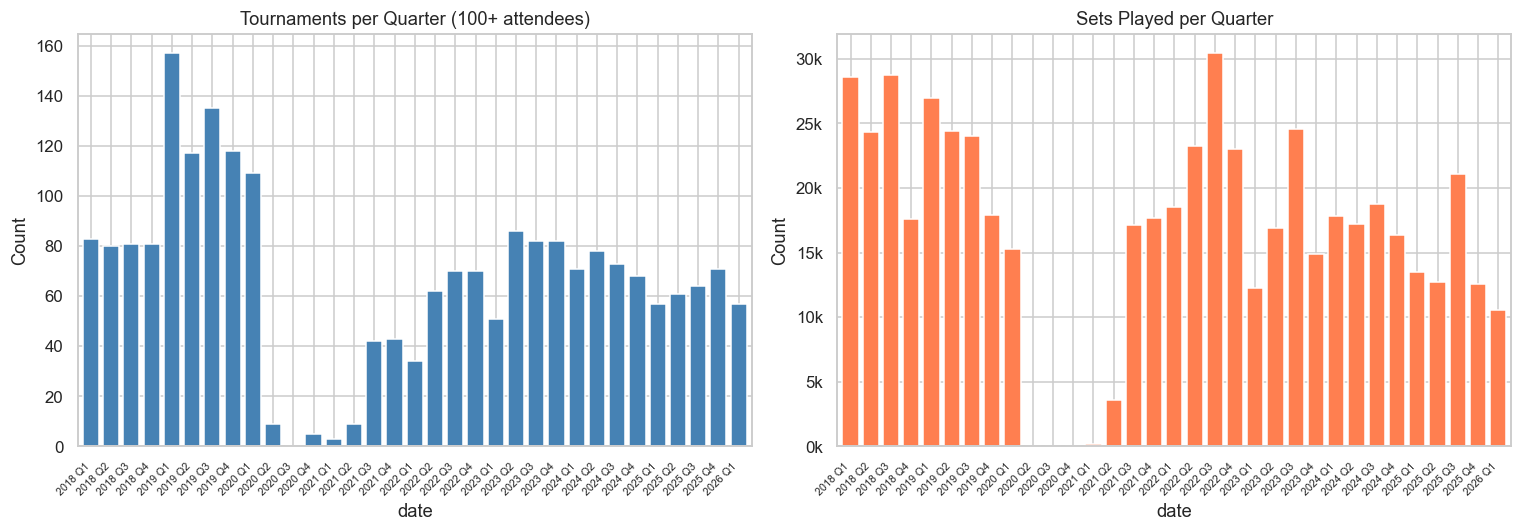

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def quarter_labels(index):
    return [f"{d.year} Q{(d.month - 1) // 3 + 1}" for d in index]

# Tournaments per quarter
quarterly = tournaments.set_index("date").resample("QS").size()
quarterly.plot(kind="bar", ax=axes[0], color="steelblue", width=0.8)
axes[0].set_title("Tournaments per Quarter (100+ attendees)")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(quarter_labels(quarterly.index), rotation=45, ha="right", fontsize=7)

# Total sets per quarter
sets_quarterly = sets.dropna(subset=["date"]).set_index("date").resample("QS").size()
sets_quarterly.plot(kind="bar", ax=axes[1], color="coral", width=0.8)
axes[1].set_title("Sets Played per Quarter")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[1].set_xticklabels(quarter_labels(sets_quarterly.index), rotation=45, ha="right", fontsize=7)

plt.tight_layout()
plt.show()

## 2. Tournament Size Distribution\nWhat does the landscape of tournament sizes look like?

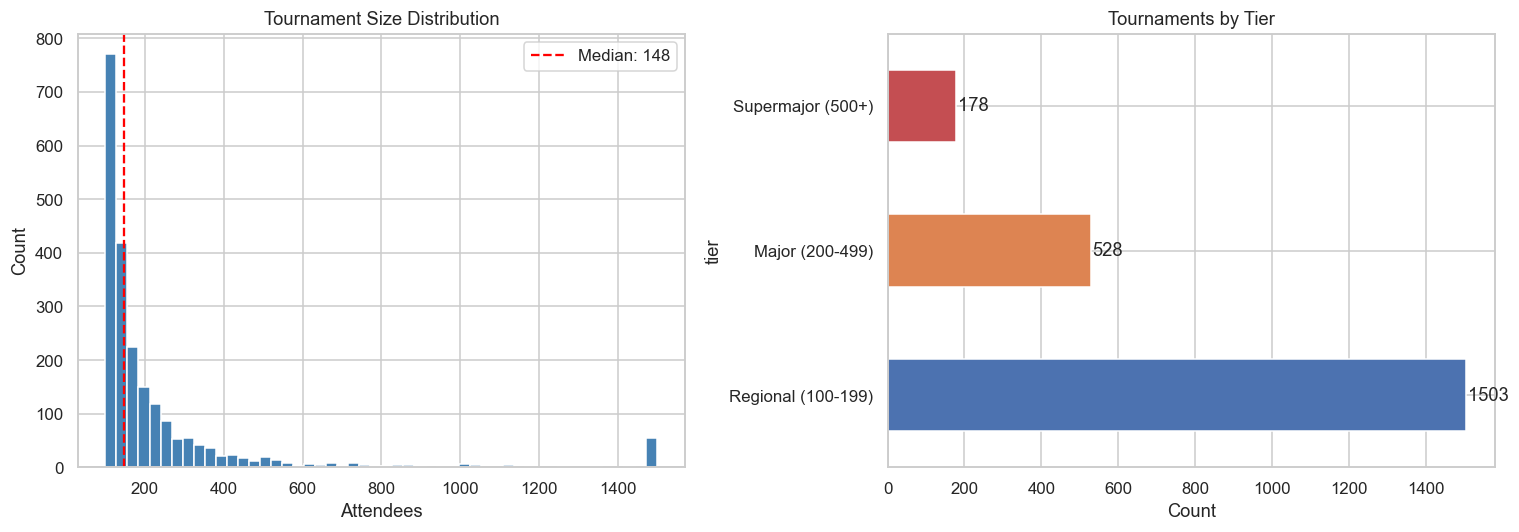


Largest tournaments:
                                name  num_attendees       date          city state
                            Evo 2018           7675 2018-08-03          None    NV
                           GENESIS X           4786 2024-02-16      San Jose    CA
                           Genesis 8           4714 2022-04-15      San Jose    CA
                      Supernova 2025           4590 2025-08-07     Chantilly    VA
                  COMBO BREAKER 2024           4525 2024-05-24    Schaumburg    IL
CEO 2019 Fighting Game Championships           4476 2019-06-28 Daytona Beach    FL
                      Supernova 2024           4388 2024-08-08     Chantilly    VA
                Super Smash Con 2023           4375 2023-08-10     Chantilly    VA
                            CEO 2025           4293 2025-06-13       Orlando    FL
                           Genesis 6           3990 2019-02-01       Oakland    CA


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of tournament sizes
tournaments["num_attendees"].clip(upper=1500).hist(
    bins=50, ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Tournament Size Distribution")
axes[0].set_xlabel("Attendees")
axes[0].set_ylabel("Count")
axes[0].axvline(tournaments["num_attendees"].median(), color="red", ls="--", label=f'Median: {tournaments["num_attendees"].median():.0f}')
axes[0].legend()

# Tier breakdown
def tier(n):
    if n >= 500: return "Supermajor (500+)"
    if n >= 200: return "Major (200-499)"
    return "Regional (100-199)"

tournaments["tier"] = tournaments["num_attendees"].apply(tier)
tier_order = ["Regional (100-199)", "Major (200-499)", "Supermajor (500+)"]
tier_counts = tournaments["tier"].value_counts().reindex(tier_order)
tier_counts.plot(kind="barh", ax=axes[1], color=["#4c72b0", "#dd8452", "#c44e52"])
axes[1].set_title("Tournaments by Tier")
axes[1].set_xlabel("Count")
for i, v in enumerate(tier_counts):
    axes[1].text(v + 5, i, str(v), va="center")

plt.tight_layout()
plt.show()

print(f"\nLargest tournaments:")
top = tournaments.nlargest(10, "num_attendees")[["name", "num_attendees", "date", "city", "state"]]
top["date"] = top["date"].dt.date
print(top.to_string(index=False))

## 3. Seed vs. Outcome — Do Higher Seeds Win?\nThis is the most fundamental question for our prediction model. If seeding already predicts outcomes well, we have a strong baseline.

Higher seed wins: 74.4% of the time (n=550,737)


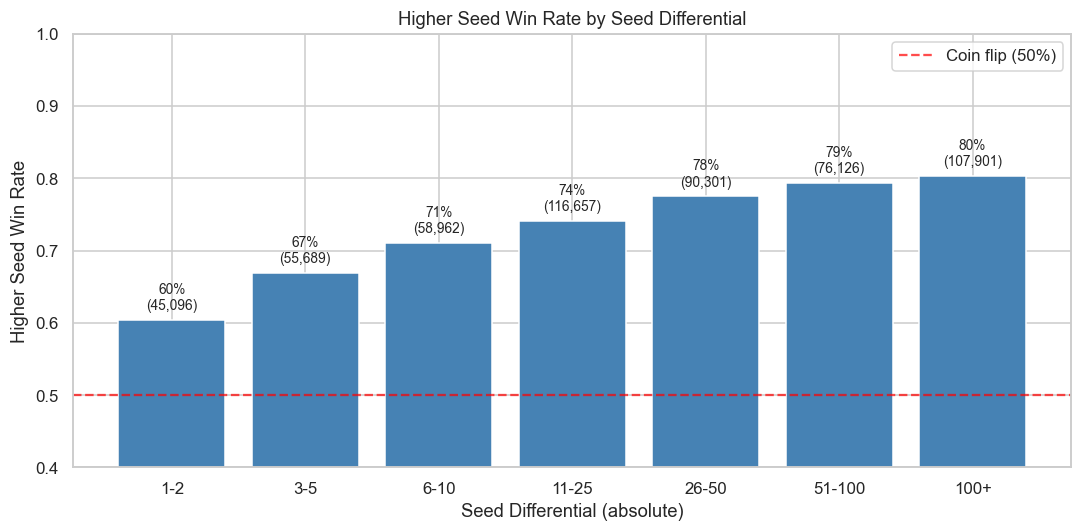

In [4]:
# Determine if the higher seed (lower seed number) won
s = sets.copy()
s["higher_seed_is_p1"] = s["player1_seed"] < s["player2_seed"]
s["higher_seed_won"] = (
    (s["higher_seed_is_p1"] & (s["winner_player_id"] == s["player1_id"])) |
    (~s["higher_seed_is_p1"] & (s["winner_player_id"] == s["player2_id"]))
)
# Exclude sets where seeds are equal
s = s[s["player1_seed"] != s["player2_seed"]]

higher_seed_win_rate = s["higher_seed_won"].mean()
print(f"Higher seed wins: {higher_seed_win_rate:.1%} of the time (n={len(s):,})")

# Win rate by seed differential bucket
s["seed_diff"] = (s["player1_seed"] - s["player2_seed"]).abs()
s["seed_diff_bucket"] = pd.cut(s["seed_diff"], bins=[0, 2, 5, 10, 25, 50, 100, 5000],
                                labels=["1-2", "3-5", "6-10", "11-25", "26-50", "51-100", "100+"])

upset_by_diff = s.groupby("seed_diff_bucket", observed=True)["higher_seed_won"].agg(["mean", "count"])
upset_by_diff.columns = ["higher_seed_win_rate", "n_sets"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(upset_by_diff.index.astype(str), upset_by_diff["higher_seed_win_rate"], 
              color="steelblue", edgecolor="white")
ax.axhline(0.5, color="red", ls="--", alpha=0.7, label="Coin flip (50%)")
ax.set_title("Higher Seed Win Rate by Seed Differential")
ax.set_xlabel("Seed Differential (absolute)")
ax.set_ylabel("Higher Seed Win Rate")
ax.set_ylim(0.4, 1.0)
ax.legend()

for bar, (_, row) in zip(bars, upset_by_diff.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{row["higher_seed_win_rate"]:.0%}\n({int(row["n_sets"]):,})', 
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 4. Player Activity Distribution\nHow many sets does a typical player have? This matters for feature reliability — Elo and head-to-head stats are noisy with few games.

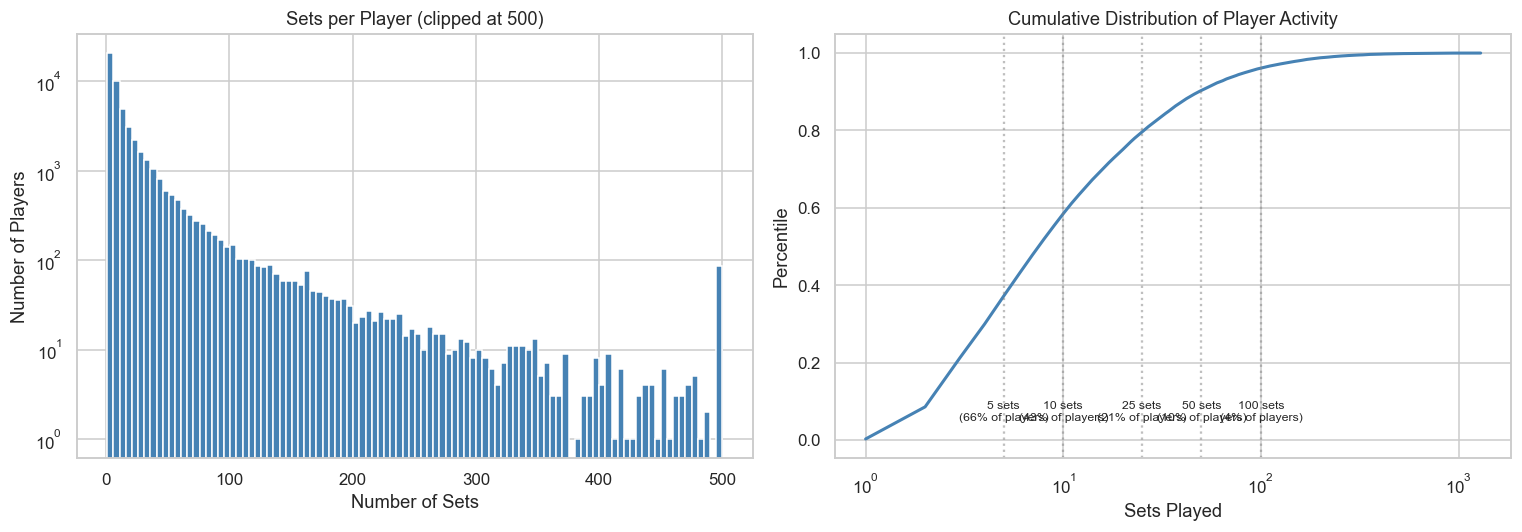

Median sets per player: 7
Mean sets per player:   21.6
Players with 10+ sets:  21,931 (43.0%)
Players with 50+ sets:  4,982 (9.8%)


In [5]:
# Count sets per player
all_appearances = pd.concat([
    sets[["player1_id"]].rename(columns={"player1_id": "player_id"}),
    sets[["player2_id"]].rename(columns={"player2_id": "player_id"}),
])
sets_per_player = all_appearances["player_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (log scale)
sets_per_player.clip(upper=500).hist(bins=100, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Sets per Player (clipped at 500)")
axes[0].set_xlabel("Number of Sets")
axes[0].set_ylabel("Number of Players")
axes[0].set_yscale("log")

# CDF
sorted_counts = sets_per_player.sort_values()
cdf = sorted_counts.rank(pct=True)
axes[1].plot(sorted_counts.values, cdf.values, color="steelblue", lw=2)
axes[1].set_title("Cumulative Distribution of Player Activity")
axes[1].set_xlabel("Sets Played")
axes[1].set_ylabel("Percentile")
axes[1].set_xscale("log")
for threshold in [5, 10, 25, 50, 100]:
    pct = (sets_per_player >= threshold).mean()
    axes[1].axvline(threshold, color="gray", ls=":", alpha=0.5)
    axes[1].text(threshold, 0.05, f"{threshold} sets\n({pct:.0%} of players)", 
                fontsize=8, ha="center")

plt.tight_layout()
plt.show()

print(f"Median sets per player: {sets_per_player.median():.0f}")
print(f"Mean sets per player:   {sets_per_player.mean():.1f}")
print(f"Players with 10+ sets:  {(sets_per_player >= 10).sum():,} ({(sets_per_player >= 10).mean():.1%})")
print(f"Players with 50+ sets:  {(sets_per_player >= 50).sum():,} ({(sets_per_player >= 50).mean():.1%})")

## 5. Top Player Dominance\nWin rates and activity of the most prolific players in the dataset.

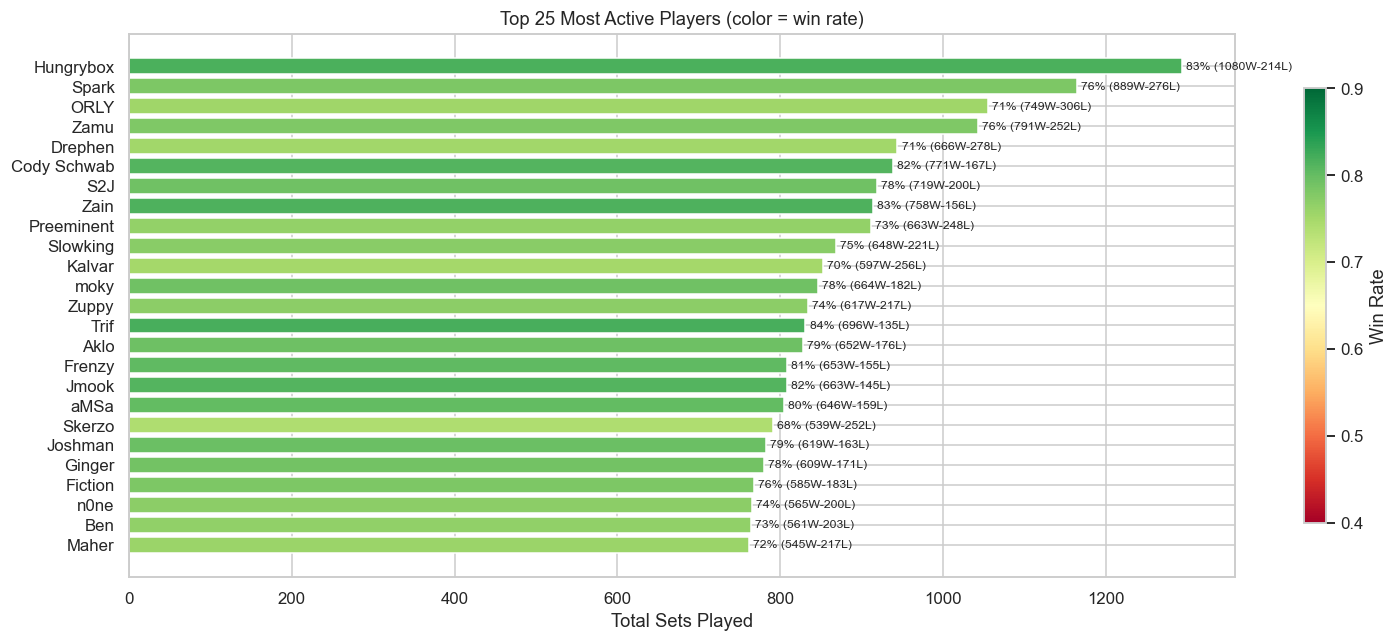

In [6]:
# Build win/loss records for all players
wins_as_p1 = sets[sets["winner_player_id"] == sets["player1_id"]].groupby("player1_id").size()
wins_as_p2 = sets[sets["winner_player_id"] == sets["player2_id"]].groupby("player2_id").size()
losses_as_p1 = sets[sets["winner_player_id"] == sets["player2_id"]].groupby("player1_id").size()
losses_as_p2 = sets[sets["winner_player_id"] == sets["player1_id"]].groupby("player2_id").size()

player_stats = pd.DataFrame({
    "wins": wins_as_p1.add(wins_as_p2, fill_value=0),
    "losses": losses_as_p1.add(losses_as_p2, fill_value=0),
}).fillna(0).astype(int)
player_stats["total"] = player_stats["wins"] + player_stats["losses"]
player_stats["win_rate"] = player_stats["wins"] / player_stats["total"]
player_stats = player_stats.join(players.set_index("id")["gamer_tag"])

# Top 25 by total sets (with win rate)
top25 = player_stats.nlargest(25, "total")

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.RdYlGn(top25["win_rate"])
bars = ax.barh(range(len(top25)), top25["total"], color=colors, edgecolor="white")
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25["gamer_tag"])
ax.invert_yaxis()
ax.set_xlabel("Total Sets Played")
ax.set_title("Top 25 Most Active Players (color = win rate)")

for i, (_, row) in enumerate(top25.iterrows()):
    ax.text(row["total"] + 5, i, f'{row["win_rate"]:.0%} ({int(row["wins"])}W-{int(row["losses"])}L)', 
            va="center", fontsize=8)

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(0.4, 0.9))
plt.colorbar(sm, ax=ax, label="Win Rate", shrink=0.8)
plt.tight_layout()
plt.show()

## 6. Head-to-Head: Top Player Rivalries\nClassic Melee rivalries — who has the edge?

In [7]:
# Build head-to-head matrix for top 15 players by win rate (min 100 sets)
top_players = player_stats[player_stats["total"] >= 100].nlargest(15, "win_rate")
top_ids = set(top_players.index)

# Filter sets to only those between top players
h2h_sets = sets[
    (sets["player1_id"].isin(top_ids)) & (sets["player2_id"].isin(top_ids))
].copy()

# Build the H2H matrix
id_to_tag = players.set_index("id")["gamer_tag"].to_dict()
h2h_records = {}

for _, row in h2h_sets.iterrows():
    p1, p2, winner = row["player1_id"], row["player2_id"], row["winner_player_id"]
    pair = (min(p1, p2), max(p1, p2))
    if pair not in h2h_records:
        h2h_records[pair] = {pair[0]: 0, pair[1]: 0}
    h2h_records[pair][winner] += 1

# Format as a readable table
h2h_rows = []
for (p1, p2), record in sorted(h2h_records.items(), key=lambda x: sum(x[1].values()), reverse=True):
    total = record[p1] + record[p2]
    if total >= 3:  # Only show matchups with 3+ sets
        h2h_rows.append({
            "Player A": id_to_tag.get(p1, p1),
            "Player B": id_to_tag.get(p2, p2),
            "A Wins": record[p1],
            "B Wins": record[p2],
            "Total": total,
        })

h2h_df = pd.DataFrame(h2h_rows).head(30)
print(f"Top 30 most-played rivalries among the best players:\n")
print(h2h_df.to_string(index=False))

Top 30 most-played rivalries among the best players:

 Player A   Player B  A Wins  B Wins  Total
Hungrybox       Zain      13      29     42
Hungrybox     Armada       1       4      5
     Zain       Trif       4       0      4
     Trif Solobattle       0       4      4
    Amsah       Trif       0       3      3
Hungrybox       Inky       2       1      3
Hungrybox       Trif       3       0      3


## 7. Game-Level Data Coverage\nOnly a fraction of sets have game-level data (character picks, stages). Where does it come from?

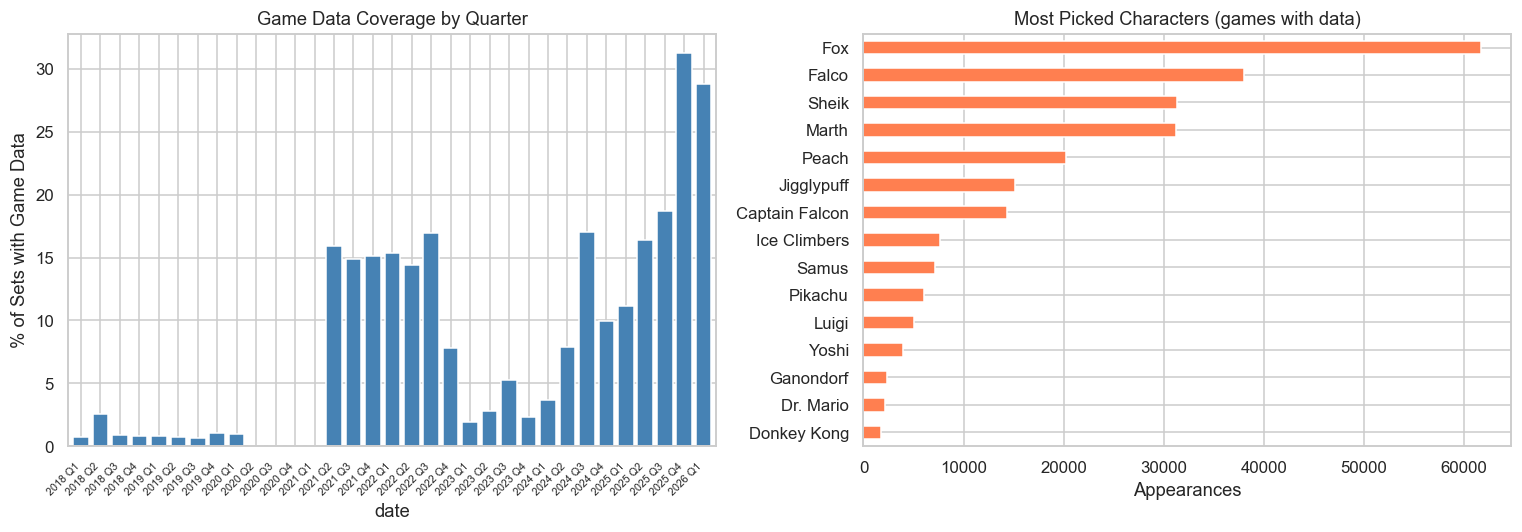


Sets with game data: 44,704 / 550,737 (8.1%)
Games with character data: 127,433 / 138,968 (91.7%)


In [8]:
# Game data coverage over time
sets_with_games = sets[sets["id"].isin(games["set_id"].unique())].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coverage rate by quarter
all_q = sets.dropna(subset=["date"]).set_index("date").resample("QS").size()
game_q = sets_with_games.dropna(subset=["date"]).set_index("date").resample("QS").size()
coverage = (game_q / all_q * 100).fillna(0)

coverage.plot(kind="bar", ax=axes[0], color="steelblue", width=0.8)
axes[0].set_title("Game Data Coverage by Quarter")
axes[0].set_ylabel("% of Sets with Game Data")
axes[0].set_xticklabels(quarter_labels(coverage.index), rotation=45, ha="right", fontsize=7)

# Character usage in games that DO have character data
char_counts = pd.concat([
    games["player1_character_name"].dropna(),
    games["player2_character_name"].dropna(),
]).value_counts().head(15)

char_counts.plot(kind="barh", ax=axes[1], color="coral", edgecolor="white")
axes[1].invert_yaxis()
axes[1].set_title("Most Picked Characters (games with data)")
axes[1].set_xlabel("Appearances")

plt.tight_layout()
plt.show()

total_sets = len(sets)
sets_w_games = len(sets_with_games)
games_w_chars = games["player1_character_name"].notna().sum()
print(f"\nSets with game data: {sets_w_games:,} / {total_sets:,} ({100*sets_w_games/total_sets:.1f}%)")
print(f"Games with character data: {games_w_chars:,} / {len(games):,} ({100*games_w_chars/len(games):.1f}%)")

## 8. Score Distribution — How Close Are Sets?\nAre most sets blowouts (3-0) or close (3-2)? This tells us how much variance there is to model.

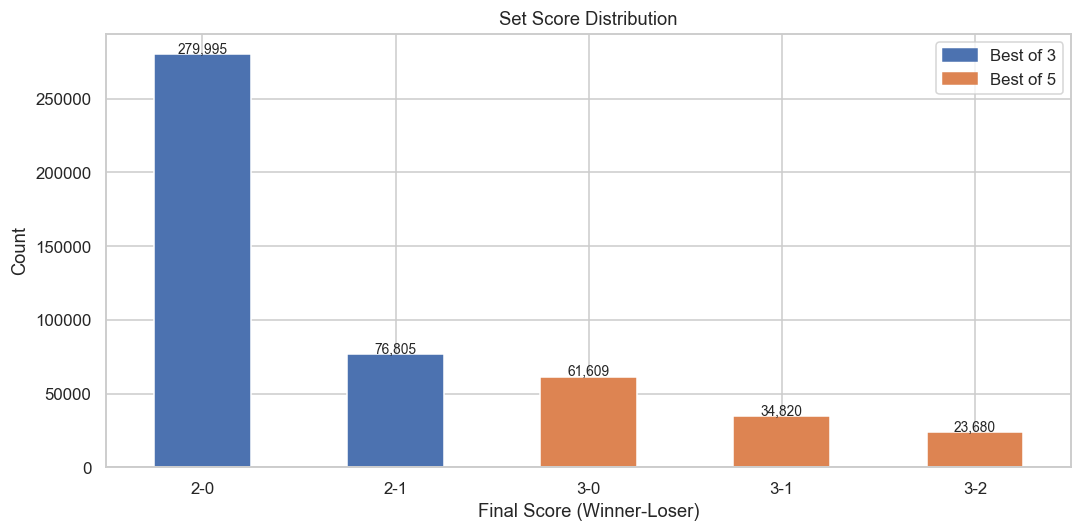


Bo3: 356,800 sets (75%)
Bo5: 120,109 sets (25%)

Bo3 — 2-0 rate: 78%
Bo5 — 3-0 rate: 51%


In [9]:
# Parse scores — player1_score and player2_score are available
scored = sets.dropna(subset=["player1_score", "player2_score"]).copy()
scored["winner_score"] = scored[["player1_score", "player2_score"]].max(axis=1).astype(int)
scored["loser_score"] = scored[["player1_score", "player2_score"]].min(axis=1).astype(int)
scored["score_line"] = scored["winner_score"].astype(str) + "-" + scored["loser_score"].astype(str)

# Filter to common best-of-3 and best-of-5 formats
bo3_scores = ["2-0", "2-1"]
bo5_scores = ["3-0", "3-1", "3-2"]
common = scored[scored["score_line"].isin(bo3_scores + bo5_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
score_counts = common["score_line"].value_counts().reindex(bo3_scores + bo5_scores)
colors = ["#4c72b0", "#4c72b0", "#dd8452", "#dd8452", "#dd8452"]
score_counts.plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.set_title("Set Score Distribution")
ax.set_xlabel("Final Score (Winner-Loser)")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for bar, count in zip(ax.patches, score_counts):
    if pd.notna(count):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f"{int(count):,}", ha="center", fontsize=9)

ax.legend(handles=[
    plt.Rectangle((0,0), 1, 1, color="#4c72b0", label="Best of 3"),
    plt.Rectangle((0,0), 1, 1, color="#dd8452", label="Best of 5"),
])

plt.tight_layout()
plt.show()

total_scored = len(common)
print(f"\nBo3: {common['score_line'].isin(bo3_scores).sum():,} sets ({common['score_line'].isin(bo3_scores).mean():.0%})")
print(f"Bo5: {common['score_line'].isin(bo5_scores).sum():,} sets ({common['score_line'].isin(bo5_scores).mean():.0%})")
bo3 = common[common["score_line"].isin(bo3_scores)]
bo5 = common[common["score_line"].isin(bo5_scores)]
print(f"\nBo3 — 2-0 rate: {(bo3['score_line'] == '2-0').mean():.0%}")
print(f"Bo5 — 3-0 rate: {(bo5['score_line'] == '3-0').mean():.0%}")

## 9. Key Takeaways for Modeling\nSummary of what we learned and how it shapes our feature engineering.

In [10]:
conn.close()

print("""
TAKEAWAYS FOR FEATURE ENGINEERING
==================================

1. SEED DIFFERENTIAL is a strong baseline predictor — higher seeds win the
   majority of sets, and win rate increases with seed gap. This will be our
   baseline feature to beat.

2. ELO RATINGS should add value beyond seeding — seeds are tournament-specific
   and don't capture cross-tournament form. A rolling Elo rating will track
   player strength over time.

3. HEAD-TO-HEAD records matter for top players — the rivalries table shows
   some matchups are lopsided. H2H features will help at the top level.

4. RECENT FORM (rolling win rate) captures momentum and slumps that static
   ratings miss.

5. CHARACTER DATA is sparse (~8%) — we can use it as an optional feature
   where available, but can't rely on it as a primary predictor.

6. PLAYER ACTIVITY varies hugely — we'll need minimum-set thresholds for
   reliable Elo ratings (probably 10+ sets).

7. TOURNAMENT SIZE/TIER affects competition level — a win at Genesis means
   more than a win at a 100-person local.
""")


TAKEAWAYS FOR FEATURE ENGINEERING

1. SEED DIFFERENTIAL is a strong baseline predictor — higher seeds win the
   majority of sets, and win rate increases with seed gap. This will be our
   baseline feature to beat.

2. ELO RATINGS should add value beyond seeding — seeds are tournament-specific
   and don't capture cross-tournament form. A rolling Elo rating will track
   player strength over time.

3. HEAD-TO-HEAD records matter for top players — the rivalries table shows
   some matchups are lopsided. H2H features will help at the top level.

4. RECENT FORM (rolling win rate) captures momentum and slumps that static
   ratings miss.

5. CHARACTER DATA is sparse (~8%) — we can use it as an optional feature
   where available, but can't rely on it as a primary predictor.

6. PLAYER ACTIVITY varies hugely — we'll need minimum-set thresholds for
   reliable Elo ratings (probably 10+ sets).

7. TOURNAMENT SIZE/TIER affects competition level — a win at Genesis means
   more than a win at a